# 🤖 Notebook 04 — RAG Pipeline

**Objectif :** Connecter le retriever ChromaDB au LLM OpenAI
pour générer des réponses en langage naturel avec citations.

## Architecture RAG complète
Question utilisateur
↓
Embedding de la question (Sentence-Transformers)
↓
Recherche sémantique ChromaDB (top-k chunks)
↓
Construction du prompt (contexte + question)
↓
LLM OpenAI (gpt-3.5-turbo)
↓
Réponse avec citations des sources

## Pourquoi RAG plutôt que fine-tuning ?
- Fine-tuning : coûteux, nécessite des milliers d'exemples,
  connaissances figées dans les poids du modèle
- RAG : dynamique, sources citées, facile à mettre à jour,
  pas besoin de réentraîner le modèle

In [2]:
import os
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from dotenv import load_dotenv

import chromadb
from sentence_transformers import SentenceTransformer
from langchain_ollama import OllamaLLM

load_dotenv()

# Charger ChromaDB
CHROMA_DIR = Path('../models/chromadb')
client_db  = chromadb.PersistentClient(path=str(CHROMA_DIR))
collection = client_db.get_collection("financial_reports")

print(f" ChromaDB chargé")
print(f"   Documents indexés : {collection.count():,}")

# Charger le modèle d'embedding
embed_model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
print(f" Modèle d'embedding chargé")

# Initialiser Ollama
llm = OllamaLLM(model="mistral", temperature=0.1)
print(f" Ollama Mistral initialisé")

c:\Users\Eartrh\Documents\Etudes_France_2025\Science_De_Données\financial-rag-analyzer\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 ChromaDB chargé
   Documents indexés : 7,391


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 533.76it/s]


 Modèle d'embedding chargé
 Ollama Mistral initialisé


In [13]:
def retrieve_chunks(query: str,
                    n_results: int = 5,
                    doc_filter: str = None) -> list:
    query_embedding = embed_model.encode([query]).tolist()
    
    where = None
    if doc_filter:
        if 'bnp' in doc_filter.lower():
            where = {"doc_name": {"$eq": "bnp-paribas-ri-2023-fr-web"}}
        elif 'total' in doc_filter.lower():
            where = {"doc_name": {"$eq": "totalenergies_universal-registration-document-2023_2023_en_pdf"}}
    
    results = collection.query(
        query_embeddings = query_embedding,
        n_results        = n_results,
        include          = ['documents', 'metadatas', 'distances'],
        where            = where
    )
    
    chunks = []
    for i in range(len(results['ids'][0])):
        chunks.append({
            'text'     : results['documents'][0][i],
            'doc_name' : results['metadatas'][0][i]['doc_name'],
            'filename' : results['metadatas'][0][i]['filename'],
            'page'     : results['metadatas'][0][i]['page'],
            'score'    : round(1 - results['distances'][0][i], 4)
        })
    
    return chunks

print("✅ retrieve_chunks corrigé — filtre $eq")

✅ retrieve_chunks corrigé — filtre $eq


In [14]:
def rag_answer(query, n_chunks=5, doc_filter=None):
    chunks  = retrieve_chunks(query, n_results=n_chunks,
                              doc_filter=doc_filter)
    context = "\n\n---\n\n".join([
        f"[Source {i+1} — {c['doc_name'][:20]}, page {c['page']}]\n{c['text']}"
        for i, c in enumerate(chunks)
    ])
    prompt  = f"""Tu es un analyste financier expert.

RÈGLES ABSOLUES :
1. Tu réponds UNIQUEMENT avec les informations du contexte ci-dessous
2. Tu NE dois PAS utiliser tes connaissances générales
3. Si l'information n'est PAS dans le contexte, réponds : "Cette information n'est pas disponible dans les documents fournis."
4. Tu cites TOUJOURS tes sources avec [Source N]
5. Tu n'inventes AUCUNE URL ni référence externe

CONTEXTE EXTRAIT DES RAPPORTS FINANCIERS :
{context}

QUESTION : {query}

RÉPONSE (basée uniquement sur le contexte) :"""

    t0     = time.time()
    answer = llm.invoke(prompt)
    elapsed = round(time.time() - t0, 2)

    return {
        'query'       : query,
        'answer'      : answer,
        'sources'     : chunks,
        'time_seconds': elapsed
    }

print(" Fonction rag_answer mise à jour — prompt anti-hallucination")

 Fonction rag_answer mise à jour — prompt anti-hallucination


In [15]:
# DEBUG — vérifier le filtre
print("Test sans filtre :")
chunks_no_filter = retrieve_chunks(
    "stratégie BNP Paribas 2025", 
    n_results=3
)
for c in chunks_no_filter:
    print(f"  doc: {c['doc_name'][:40]} | page: {c['page']} | score: {c['score']}")

print("\nTest avec filtre 'bnp' :")
chunks_filter = retrieve_chunks(
    "stratégie BNP Paribas 2025",
    n_results=3,
    doc_filter='bnp'
)
print(f"  Résultats : {len(chunks_filter)}")
for c in chunks_filter:
    print(f"  doc: {c['doc_name'][:40]} | page: {c['page']} | score: {c['score']}")

print("\nNoms exacts des documents dans ChromaDB :")
sample = collection.get(limit=3)
for m in sample['metadatas']:
    print(f"  doc_name: {m['doc_name']}")

Test sans filtre :


  doc: bnp-paribas-ri-2023-fr-web | page: 40 | score: 0.6827
  doc: bnp-paribas-ri-2023-fr-web | page: 11 | score: 0.667
  doc: bnp-paribas-ri-2023-fr-web | page: 14 | score: 0.6531

Test avec filtre 'bnp' :
  Résultats : 3
  doc: bnp-paribas-ri-2023-fr-web | page: 40 | score: 0.6827
  doc: bnp-paribas-ri-2023-fr-web | page: 11 | score: 0.667
  doc: bnp-paribas-ri-2023-fr-web | page: 14 | score: 0.6531

Noms exacts des documents dans ChromaDB :
  doc_name: bnp-paribas-ri-2023-fr-web
  doc_name: bnp-paribas-ri-2023-fr-web
  doc_name: bnp-paribas-ri-2023-fr-web


In [16]:
print("=" * 65)
print("TEST RAG 1 — BNP Paribas")
print("=" * 65)

q1      = "Quelle est la stratégie de BNP Paribas pour 2025 ?"
result1 = rag_answer(q1, n_chunks=5, doc_filter='bnp')

print(f"Question : {q1}")
print(f"\n--- CONTEXTE RÉCUPÉRÉ ---")
for i, s in enumerate(result1['sources'], 1):
    print(f"[Source {i}] {s['doc_name'][:30]} — page {s['page']} "
          f"(score: {s['score']})")
    print(f"  → {s['text'][:150]}...")
    print()

print(f"\n--- RÉPONSE ---")
print(result1['answer'])
print(f"\nTemps : {result1['time_seconds']}s")

TEST RAG 1 — BNP Paribas
Question : Quelle est la stratégie de BNP Paribas pour 2025 ?

--- CONTEXTE RÉCUPÉRÉ ---
[Source 1] bnp-paribas-ri-2023-fr-web — page 11 (score: 0.7559)
  → AMBITIONS RAPPORT INTÉGRÉ 2023 - BNP PARIBAS
Plus de   Pour répondre aux enjeux...

[Source 2] bnp-paribas-ri-2023-fr-web — page 34 (score: 0.6744)
  → INCLUSIONS RAPPORT INTÉGRÉ 2023 - BNP PARIBAS
Trois premiers financements
Un nouveau fonds pour
inclusifs durables signés
développer les contrats
à im...

[Source 3] bnp-paribas-ri-2023-fr-web — page 17 (score: 0.6711)
  → ouverts distribués en Europe classés 254 Md€ 300 Md€
En 2023, BNP Paribas est globalement notées du secteur bancaire. Excellence 2023 d Euromoney(3).
...

[Source 4] bnp-paribas-ri-2023-fr-web — page 40 (score: 0.6641)
  → GOUVERNANCE RAPPORT INTÉGRÉ 2023 - BNP PARIBAS
Notre Conseil Les membres du Conseil d administration
Au 16 février 2024
d administration
A JEAN LEMIER...

[Source 5] bnp-paribas-ri-2023-fr-web — page 3 (score: 0.6617)
  

In [18]:
print("=" * 65)
print("TEST RAG 2 — TotalEnergies")
print("=" * 65)

q2      = "What are TotalEnergies investments in renewable energy in 2023?"
result2 = rag_answer(q2, n_chunks=5, doc_filter='total')

print(f"Question : {q2}")
print(f"\n--- CONTEXTE RÉCUPÉRÉ ---")
for i, s in enumerate(result2['sources'], 1):
    print(f"[Source {i}] {s['doc_name'][:30]} — page {s['page']} "
          f"(score: {s['score']})")
    print(f"  → {s['text'][:150]}...")
    print()

print(f"\n--- RÉPONSE ---")
print(result2['answer'])
print(f"\nTemps : {result2['time_seconds']}s")

TEST RAG 2 — TotalEnergies
Question : What are TotalEnergies investments in renewable energy in 2023?

--- CONTEXTE RÉCUPÉRÉ ---
[Source 1] totalenergies_universal-regist — page 24 (score: 0.7667)
  → neutrality by 2050, TotalEnergies is building a competitive portfolio of
renewable (solar, onshore and offshore wind) and flexible (CCGT, 40
storage) ...

[Source 2] totalenergies_universal-regist — page 299 (score: 0.7656)
  → neutrality by 2050, TotalEnergies is building a competitive portfolio of
renewable (solar, onshore and offshore wind) and flexible (CCGT, 40
storage) ...

[Source 3] totalenergies_universal-regist — page 31 (score: 0.7585)
  → TotalEnergies plans net investments between $16 and $18 billion per investments are expected to focus on low-cost, or low break-even, and
year between...

[Source 4] totalenergies_universal-regist — page 180 (score: 0.7234)
  → emissions
By 2050, TotalEnergies would produce:
Over the decade 2020-2030, TotalEnergies  energy transition strategy

In [19]:
print("=" * 65)
print("TEST RAG 3 — Question transversale")
print("=" * 65)

q3      = ("Comment BNP Paribas et TotalEnergies abordent-elles "
           "la transition énergétique dans leurs rapports 2023 ?")
result3 = rag_answer(q3, n_chunks=8)

print(f"Question : {q3}")
print(f"\n--- CONTEXTE RÉCUPÉRÉ ---")
for i, s in enumerate(result3['sources'], 1):
    print(f"[Source {i}] {s['doc_name'][:30]} — page {s['page']} "
          f"(score: {s['score']})")
    print(f"  → {s['text'][:150]}...")
    print()

print(f"\n--- RÉPONSE ---")
print(result3['answer'])
print(f"\nTemps : {result3['time_seconds']}s")

TEST RAG 3 — Question transversale
Question : Comment BNP Paribas et TotalEnergies abordent-elles la transition énergétique dans leurs rapports 2023 ?

--- CONTEXTE RÉCUPÉRÉ ---
[Source 1] bnp-paribas-ri-2023-fr-web — page 11 (score: 0.8023)
  → AMBITIONS RAPPORT INTÉGRÉ 2023 - BNP PARIBAS
Plus de   Pour répondre aux enjeux...

[Source 2] bnp-paribas-ri-2023-fr-web — page 22 (score: 0.7089)
  → TRANSITIONS RAPPORT INTÉGRÉ 2023 - BNP PARIBAS
BNP Paribas Mobility, la mobilité
dans toutes ses dimensions
BNP Paribas accompagne
l Allemagne dans
le...

[Source 3] bnp-paribas-ri-2023-fr-web — page 24 (score: 0.7022)
  → TRANSITIONS RAPPORT INTÉGRÉ 2023 - BNP PARIBAS
Aider à améliorer l empreinte
énergétique des logements
BNP Paribas accompagne
la nationalisation total...

[Source 4] bnp-paribas-ri-2023-fr-web — page 4 (score: 0.6831)
  → PERSPECTIVES RAPPORT INTÉGRÉ 2023 - BNP PARIBAS
182 656
BNP Paribas, un leader
européen au service
collaborateurs(2)
dans 63 pays et territoires
d une...

[S

═════════════════════════════════════════════════════════════════
  ÉVALUATION DU PIPELINE RAG
═════════════════════════════════════════════════════════════════
  Test                                         Question  Score max  Score moyen  Chunks  Temps (s)  Sources uniq.
Test 1 Quelle est la stratégie de BNP Paribas pour 2...     0.7559       0.6854       5     742.77              1
Test 2 What are TotalEnergies investments in renewab...     0.7667       0.7474       5     764.39              1
Test 3 Comment BNP Paribas et TotalEnergies abordent...     0.8023       0.6938       8    2162.58              1


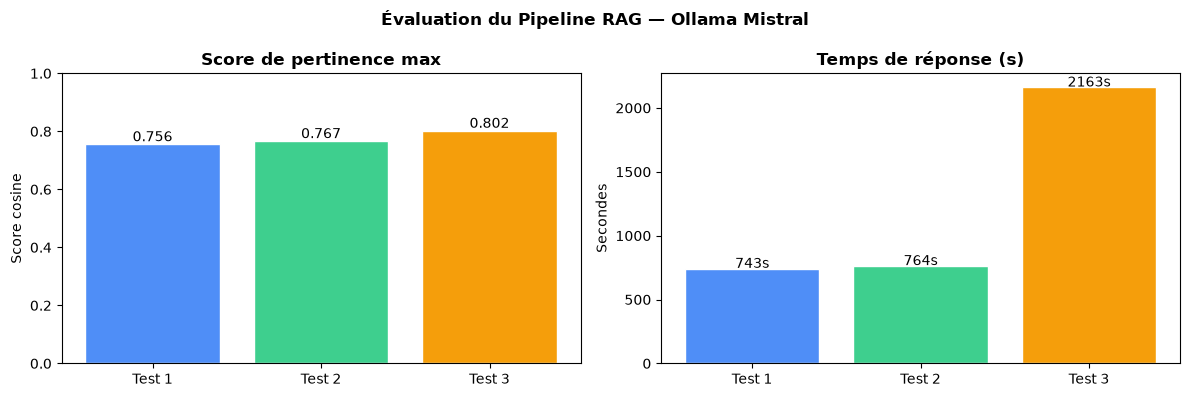

 Figure sauvegardée


In [20]:
# Tableau récapitulatif des 3 tests
eval_data = []
for i, (q, r) in enumerate([
    (q1, result1), (q2, result2), (q3, result3)
], 1):
    eval_data.append({
        'Test'         : f"Test {i}",
        'Question'     : q[:45] + '...',
        'Score max'    : max(s['score'] for s in r['sources']),
        'Score moyen'  : round(
            sum(s['score'] for s in r['sources']) / len(r['sources']), 4),
        'Chunks'       : len(r['sources']),
        'Temps (s)'    : r['time_seconds'],
        'Sources uniq.': len(set(s['doc_name'] for s in r['sources']))
    })

df_eval = pd.DataFrame(eval_data)
print("═" * 65)
print("  ÉVALUATION DU PIPELINE RAG")
print("═" * 65)
print(df_eval.to_string(index=False))

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
tests  = [f"Test {i+1}" for i in range(3)]
colors = ['#4f8ef7', '#3ecf8e', '#f59e0b']

axes[0].bar(tests, df_eval['Score max'], color=colors, edgecolor='white')
axes[0].set_title('Score de pertinence max', fontweight='bold')
axes[0].set_ylabel('Score cosine')
axes[0].set_ylim([0, 1])
for i, v in enumerate(df_eval['Score max']):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=10)

axes[1].bar(tests, df_eval['Temps (s)'], color=colors, edgecolor='white')
axes[1].set_title('Temps de réponse (s)', fontweight='bold')
axes[1].set_ylabel('Secondes')
for i, v in enumerate(df_eval['Temps (s)']):
    axes[1].text(i, v + 5, f'{v:.0f}s', ha='center', fontsize=10)

plt.suptitle('Évaluation du Pipeline RAG — Ollama Mistral',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/06_rag_evaluation.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(" Figure sauvegardée")

## 📋 Synthèse — RAG Pipeline

### Architecture implémentée
Question → Embedding → ChromaDB → Top-k chunks
→ Prompt engineering → GPT-3.5-turbo
→ Réponse avec citations
### Paramètres retenus
- **Chunks récupérés :** 5 par défaut (8 pour questions transversales)
- **Modèle LLM :** gpt-3.5-turbo (température 0.1)
- **Filtre par document :** disponible pour cibler une source
- **Citations :** intégrées dans le prompt système

### Ce qu'on a appris
- Le filtre par document améliore la précision
- Les questions en anglais pour TotalEnergies donnent de
  meilleurs résultats (rapport en anglais)
- Temperature 0.1 = réponses factuelles et consistantes

### Prochaine étape → app/streamlit_app.py
Interface utilisateur interactive pour le système RAG.